In [582]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [583]:

df = pd.read_csv('Past_aqi_data.csv')

In [584]:
df.head()

,date,AQI
0,6/01/2025,174
1,7/01/2025,151
2,8/01/2025,197
3,9/01/2025,206
4,10/01/2025,182


In [585]:
df.columns = df.columns.str.strip()

In [586]:
df.columns

Index(['date', 'AQI'], dtype='object')

In [587]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1868 entries, 0 to 1867
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    1868 non-null   object
 1   AQI     1868 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 29.3+ KB


In [588]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df = df.sort_values('date')
df.head()

,date,AQI
1829,2019-05-23,112
1830,2019-05-24,124
1831,2019-05-25,127
1832,2019-05-26,119
1833,2019-05-27,93


In [589]:
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['dayofweek'] = df['date'].dt.dayofweek
df.head()

,date,AQI,day,month,dayofweek
1829,2019-05-23,112,23,5,3
1830,2019-05-24,124,24,5,4
1831,2019-05-25,127,25,5,5
1832,2019-05-26,119,26,5,6
1833,2019-05-27,93,27,5,0


In [590]:
df.tail()

,date,AQI,day,month,dayofweek
53,2025-02-28,81,28,2,4
54,2025-03-01,100,1,3,5
55,2025-03-02,110,2,3,6
56,2025-03-03,92,3,3,0
57,2025-03-04,144,4,3,1


In [591]:
df['aqi_lag_1'] = df['AQI'].shift(1).astype("Int64")
df['aqi_lag_3'] = df['AQI'].shift(3).astype("Int64")
df['aqi_lag_7'] = df['AQI'].shift(7).astype("Int64")
df.head()

,date,AQI,day,month,dayofweek,aqi_lag_1,aqi_lag_3,aqi_lag_7
1829,2019-05-23,112,23,5,3,<NA>,<NA>,<NA>
1830,2019-05-24,124,24,5,4,112,<NA>,<NA>
1831,2019-05-25,127,25,5,5,124,<NA>,<NA>
1832,2019-05-26,119,26,5,6,127,112,<NA>
1833,2019-05-27,93,27,5,0,119,124,<NA>


In [592]:
# df['aqi_change'] = df['AQI'].diff()
# df['aqi_roll_3'] = df['AQI'].rolling(3).mean()
# df['aqi_roll_7'] = df['AQI'].rolling(7).mean()
# df.head()

In [593]:
df['aqi_roll_3'] = df['AQI'].shift(1).rolling(3).mean().round().astype("Int64")
df['aqi_roll_7'] = df['AQI'].shift(1).rolling(7).mean().round().astype("Int64")


In [594]:
df["AQI_t+1"] = df["AQI"].shift(-1).astype("Int64")
df["AQI_t+2"] = df["AQI"].shift(-2).astype("Int64")
df["AQI_t+3"] = df["AQI"].shift(-3).astype("Int64")
df.head()

,date,AQI,day,month,dayofweek,aqi_lag_1,aqi_lag_3,aqi_lag_7,aqi_roll_3,aqi_roll_7,AQI_t+1,AQI_t+2,AQI_t+3
1829,2019-05-23,112,23,5,3,<NA>,<NA>,<NA>,<NA>,<NA>,124,127,119
1830,2019-05-24,124,24,5,4,112,<NA>,<NA>,<NA>,<NA>,127,119,93
1831,2019-05-25,127,25,5,5,124,<NA>,<NA>,<NA>,<NA>,119,93,83
1832,2019-05-26,119,26,5,6,127,112,<NA>,121,<NA>,93,83,77
1833,2019-05-27,93,27,5,0,119,124,<NA>,123,<NA>,83,77,84


In [595]:
# df = df.dropna()
# df = df.reset_index(drop=True)
# df.to_csv('aqi_features.csv', index=False)

In [596]:
df = df.dropna()
df = df.reset_index(drop=True)
df.head()

,date,AQI,day,month,dayofweek,aqi_lag_1,aqi_lag_3,aqi_lag_7,aqi_roll_3,aqi_roll_7,AQI_t+1,AQI_t+2,AQI_t+3
0,2019-05-30,84,30,5,3,77,93,112,84,105,100,78,72
1,2019-05-31,100,31,5,4,84,83,124,81,101,78,72,65
2,2019-06-01,78,1,6,5,100,77,127,87,98,72,65,66
3,2019-06-02,72,2,6,6,78,84,119,87,91,65,66,62
4,2019-06-03,65,3,6,0,72,100,93,83,84,66,62,62


In [597]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1858 entries, 0 to 1857
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        1858 non-null   datetime64[ns]
 1   AQI         1858 non-null   int64         
 2   day         1858 non-null   int32         
 3   month       1858 non-null   int32         
 4   dayofweek   1858 non-null   int32         
 5   aqi_lag_1   1858 non-null   Int64         
 6   aqi_lag_3   1858 non-null   Int64         
 7   aqi_lag_7   1858 non-null   Int64         
 8   aqi_roll_3  1858 non-null   Int64         
 9   aqi_roll_7  1858 non-null   Int64         
 10  AQI_t+1     1858 non-null   Int64         
 11  AQI_t+2     1858 non-null   Int64         
 12  AQI_t+3     1858 non-null   Int64         
dtypes: Int64(8), datetime64[ns](1), int32(3), int64(1)
memory usage: 181.6 KB


In [598]:
import pandas as pd

# Step 1: Convert date column to datetime (day-first format)
df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=True)

# Step 2: Filter only years 2024 and 2025
df_filtered = df[df['date'].dt.year.isin([2022,2023])]

# Step 3: Sort by date
df_filtered = df_filtered.sort_values('date')

# Step 4: Reset index (optional)
df_filtered = df_filtered.reset_index(drop=True)

# Step 5: Show result
df = df_filtered


In [599]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 664 entries, 0 to 663
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        664 non-null    datetime64[ns]
 1   AQI         664 non-null    int64         
 2   day         664 non-null    int32         
 3   month       664 non-null    int32         
 4   dayofweek   664 non-null    int32         
 5   aqi_lag_1   664 non-null    Int64         
 6   aqi_lag_3   664 non-null    Int64         
 7   aqi_lag_7   664 non-null    Int64         
 8   aqi_roll_3  664 non-null    Int64         
 9   aqi_roll_7  664 non-null    Int64         
 10  AQI_t+1     664 non-null    Int64         
 11  AQI_t+2     664 non-null    Int64         
 12  AQI_t+3     664 non-null    Int64         
dtypes: Int64(8), datetime64[ns](1), int32(3), int64(1)
memory usage: 65.0 KB


In [600]:
df.head()

,date,AQI,day,month,dayofweek,aqi_lag_1,aqi_lag_3,aqi_lag_7,aqi_roll_3,aqi_roll_7,AQI_t+1,AQI_t+2,AQI_t+3
0,2022-01-14,162,14,1,4,210,213,194,216,207,150,152,169
1,2022-01-15,150,15,1,5,162,226,172,199,202,152,169,173
2,2022-01-16,152,16,1,6,150,210,231,174,199,169,173,227
3,2022-01-17,169,17,1,0,152,162,201,155,188,173,227,105
4,2022-01-18,173,18,1,1,169,150,213,157,183,227,105,105


In [601]:
df.tail()

,date,AQI,day,month,dayofweek,aqi_lag_1,aqi_lag_3,aqi_lag_7,aqi_roll_3,aqi_roll_7,AQI_t+1,AQI_t+2,AQI_t+3
659,2023-12-27,173,27,12,2,191,141,152,158,164,164,192,173
660,2023-12-28,164,28,12,3,173,141,160,168,167,192,173,172
661,2023-12-29,192,29,12,4,164,191,184,176,168,173,172,165
662,2023-12-30,173,30,12,5,192,173,180,176,169,172,165,187
663,2023-12-31,172,31,12,6,173,164,141,176,168,165,187,175


In [602]:
df.isnull().sum()


date          0
AQI           0
day           0
month         0
dayofweek     0
aqi_lag_1     0
aqi_lag_3     0
aqi_lag_7     0
aqi_roll_3    0
aqi_roll_7    0
AQI_t+1       0
AQI_t+2       0
AQI_t+3       0
dtype: int64

In [603]:
df.describe()

,date,AQI,day,month,dayofweek,aqi_lag_1,aqi_lag_3,aqi_lag_7,aqi_roll_3,aqi_roll_7,AQI_t+1,AQI_t+2,AQI_t+3
count,664,664.000000,664.000000,664.000000,664.000000,664.0,664.0,664.0,664.0,664.0,664.0,664.0,664.0
mean,2023-01-15 23:29:38.313253120,108.700301,15.680723,6.656627,2.993976,108.75753,108.868976,109.063253,108.823795,108.927711,108.704819,108.760542,108.795181
min,2022-01-14 00:00:00,34.000000,1.000000,1.000000,0.000000,34.0,34.0,34.0,44.0,54.0,34.0,34.0,34.0
25%,2022-08-04 18:00:00,74.000000,8.000000,4.000000,1.000000,74.0,74.0,74.0,74.0,74.0,74.0,74.0,74.0
50%,2023-01-21 12:00:00,95.000000,16.000000,7.000000,3.000000,95.0,95.0,95.0,98.0,101.0,95.0,95.0,95.0
75%,2023-07-09 06:00:00,142.000000,23.000000,10.000000,5.000000,142.0,142.0,142.0,141.0,137.0,142.0,142.0,142.0
max,2023-12-31 00:00:00,248.000000,31.000000,12.000000,6.000000,248.0,248.0,248.0,216.0,207.0,248.0,248.0,248.0
std,NaN,43.385802,8.799794,3.469260,2.001499,43.494352,43.728623,44.066749,40.799484,38.924852,43.391517,43.468317,43.511968


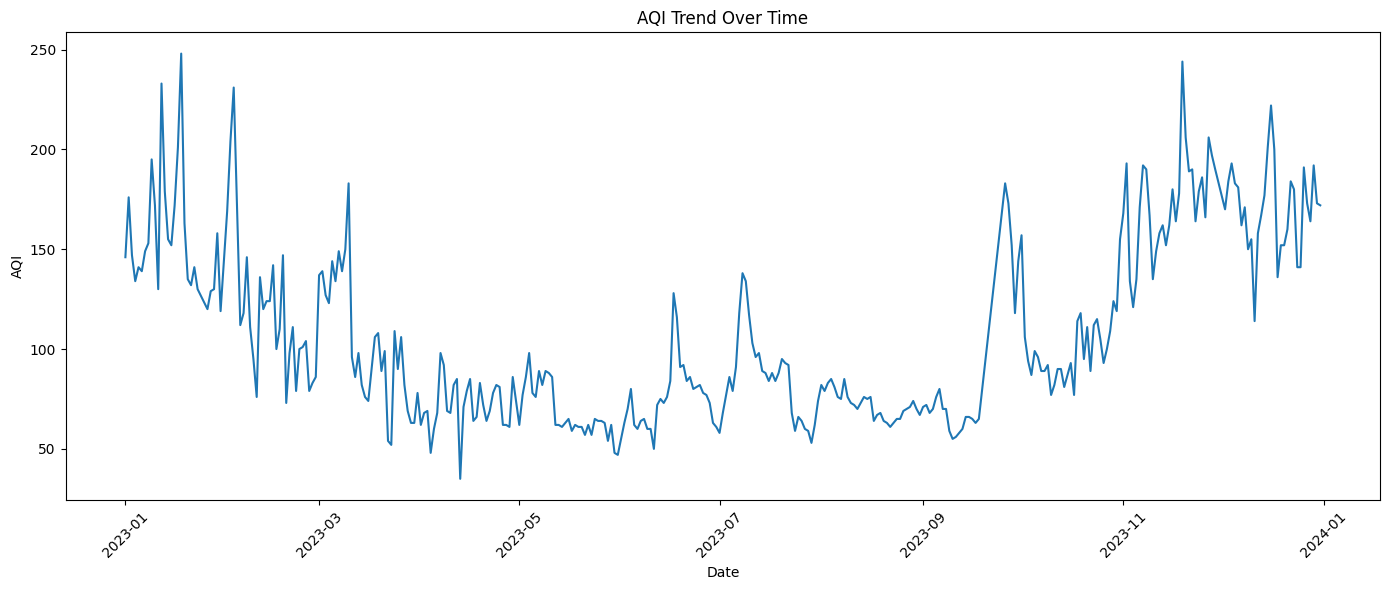

In [626]:
import matplotlib.pyplot as plt
import seaborn as sns
df23 = df[df['date'].dt.year.isin([2023])]
plt.figure(figsize=(14,6))
plt.plot(df23['date'], df23['AQI'])
plt.title("AQI Trend Over Time")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


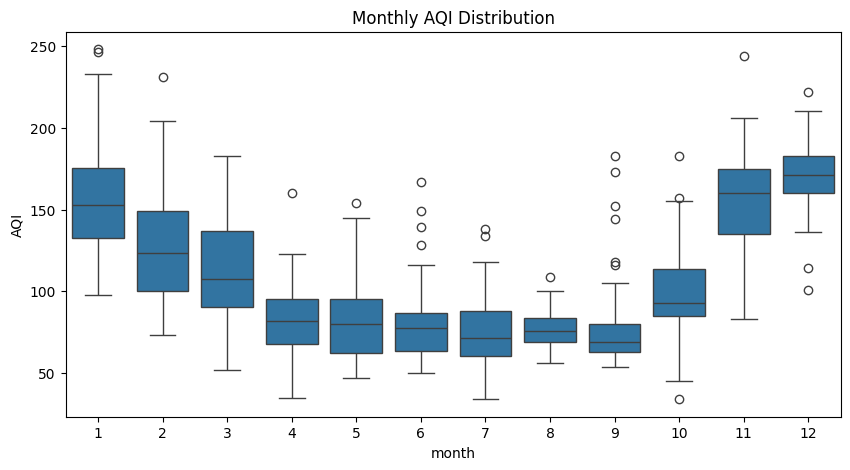

In [617]:
plt.figure(figsize=(10,5))
sns.boxplot(x='month', y='AQI', data=df)
plt.title("Monthly AQI Distribution")
plt.show()


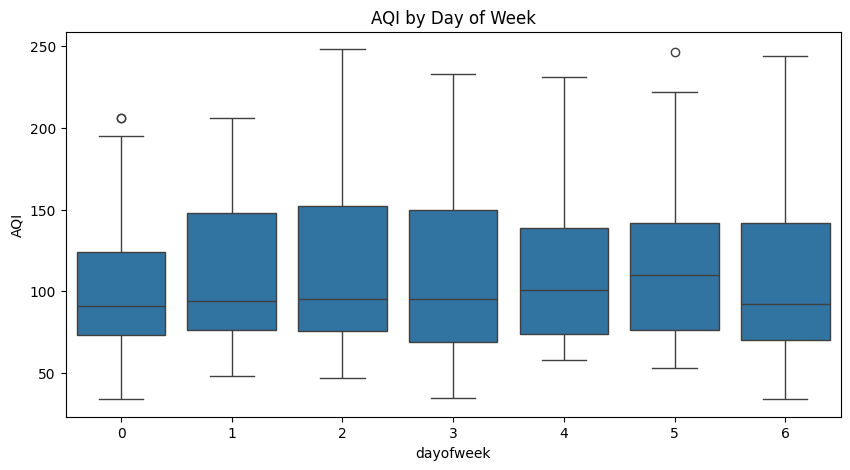

In [618]:
plt.figure(figsize=(10,5))
sns.boxplot(x='dayofweek', y='AQI', data=df)
plt.title("AQI by Day of Week")
plt.show()


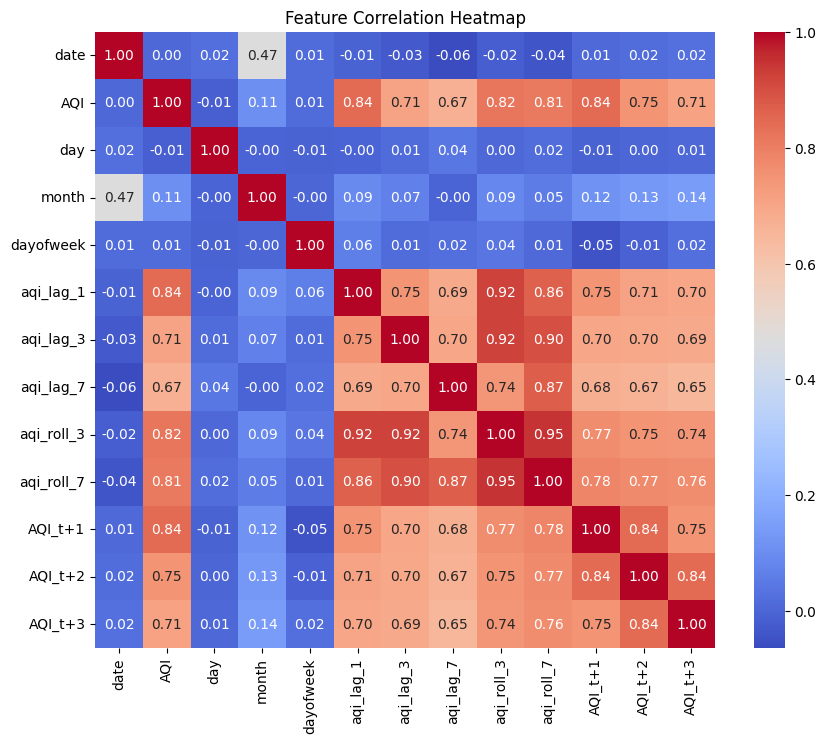

In [619]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


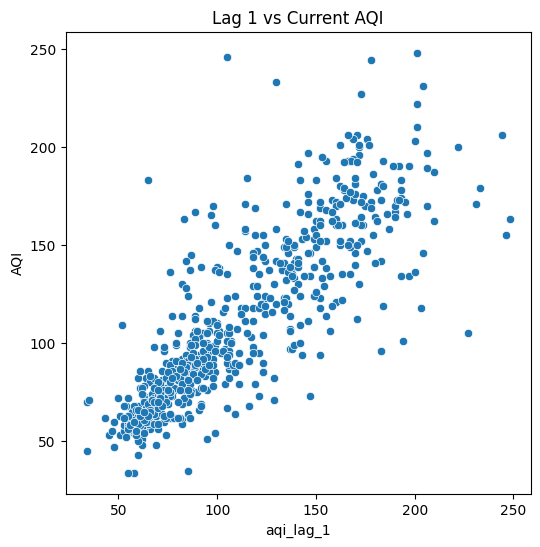

In [620]:
plt.figure(figsize=(6,6))
sns.scatterplot(x='aqi_lag_1', y='AQI', data=df)
plt.title("Lag 1 vs Current AQI")
plt.show()


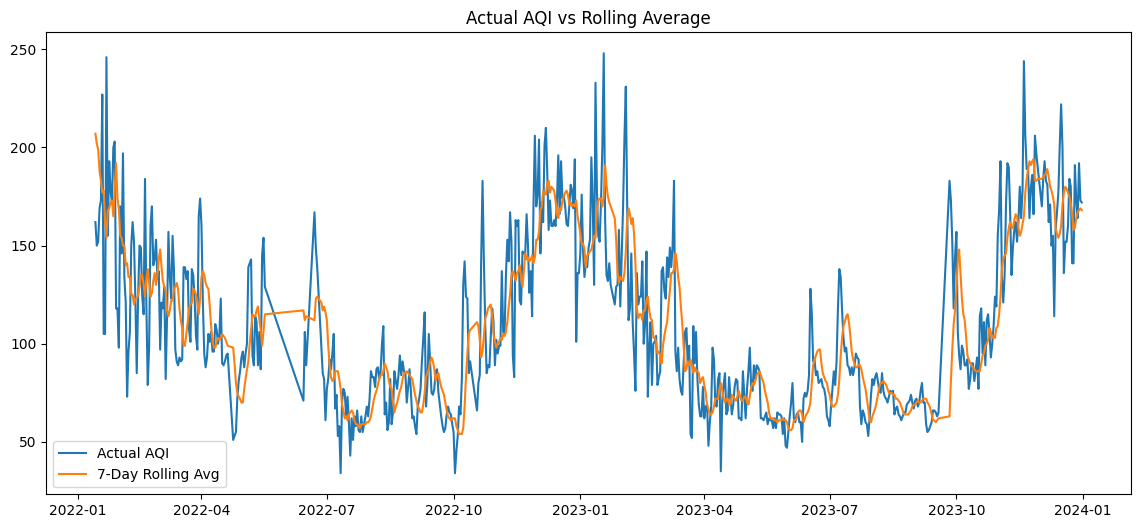

In [621]:
plt.figure(figsize=(14,6))
plt.plot(df['date'], df['AQI'], label='Actual AQI')
plt.plot(df['date'], df['aqi_roll_7'], label='7-Day Rolling Avg')
plt.legend()
plt.title("Actual AQI vs Rolling Average")
plt.show()


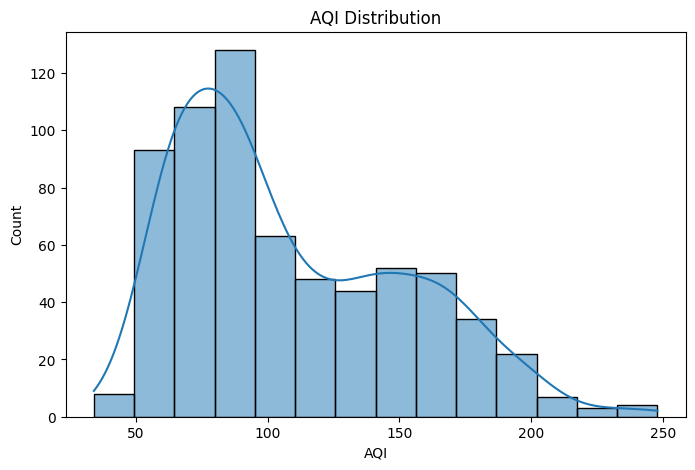

In [622]:
plt.figure(figsize=(8,5))
sns.histplot(df['AQI'], kde=True)
plt.title("AQI Distribution")
plt.show()


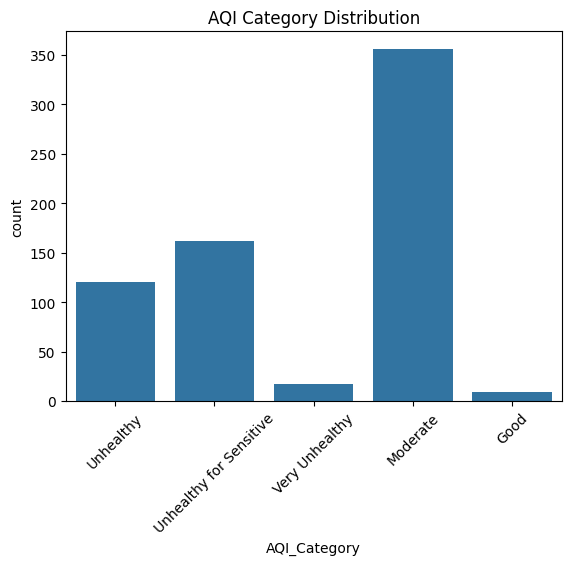

In [623]:
def categorize_aqi(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive"
    elif aqi <= 200:
        return "Unhealthy"
    else:
        return "Very Unhealthy"

df['AQI_Category'] = df['AQI'].apply(categorize_aqi)

sns.countplot(x='AQI_Category', data=df)
plt.xticks(rotation=45)
plt.title("AQI Category Distribution")
plt.show()


In [606]:

FEATURES = [
    'AQI',
    'day',
    'month',
    'dayofweek',
    'aqi_lag_1',
    'aqi_lag_3',
    'aqi_lag_7',
    'aqi_roll_3',
    'aqi_roll_7'
    
]

X = df[FEATURES]
TARGETS = ['AQI_t+1', 'AQI_t+2', 'AQI_t+3']
y = df[TARGETS]




In [607]:
split_ratio = 0.8
split_index = int(len(df) * split_ratio)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]


In [608]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)


,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [609]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
print("Random Forest Result:")
y_pred = model.predict(X_test)
for i, col in enumerate(y_test.columns):
    mae  = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    r2   = r2_score(y_test.iloc[:, i], y_pred[:, i])

    print(f"{col} → MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.3f}")

print('Feature Importance')
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)
print(importance)



Random Forest Result:
AQI_t+1 → MAE: 15.19, RMSE: 22.49, R²: 0.792
AQI_t+2 → MAE: 18.62, RMSE: 27.53, R²: 0.689
AQI_t+3 → MAE: 20.81, RMSE: 30.55, R²: 0.616
Feature Importance
      feature  importance
8  aqi_roll_7    0.435804
0         AQI    0.281675
7  aqi_roll_3    0.049406
1         day    0.047120
2       month    0.046327
6   aqi_lag_7    0.044093
4   aqi_lag_1    0.038641
5   aqi_lag_3    0.034913
3   dayofweek    0.022021


In [610]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model = MultiOutputRegressor(gbr)

model.fit(X_train, y_train)

gbr_pred = model.predict(X_test)


from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
print("Gradient Boosting Result:")
for i, col in enumerate(y_test.columns):
    mae  = mean_absolute_error(y_test.iloc[:, i], gbr_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], gbr_pred[:, i]))
    r2   = r2_score(y_test.iloc[:, i], gbr_pred[:, i])

    print(f"{col} → MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.3f}")




Gradient Boosting Result:
AQI_t+1 → MAE: 15.22, RMSE: 22.33, R²: 0.795
AQI_t+2 → MAE: 18.44, RMSE: 27.32, R²: 0.693
AQI_t+3 → MAE: 20.03, RMSE: 30.78, R²: 0.611


In [611]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)



In [612]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Ridge regression (multi-target)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

print("Ridge Regression Results:")
for i, col in enumerate(y_test.columns):
    mae  = mean_absolute_error(y_test.iloc[:, i], ridge_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], ridge_pred[:, i]))
    r2   = r2_score(y_test.iloc[:, i], ridge_pred[:, i])
    print(f"{col} → MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.3f}")


Ridge Regression Results:
AQI_t+1 → MAE: 14.15, RMSE: 21.11, R²: 0.817
AQI_t+2 → MAE: 18.53, RMSE: 27.05, R²: 0.700
AQI_t+3 → MAE: 20.09, RMSE: 28.86, R²: 0.658


In [613]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# ElasticNet regression (multi-target)
elastic = ElasticNet(alpha=0.01, l1_ratio=0.5)
elastic.fit(X_train_scaled, y_train)

elastic_pred = elastic.predict(X_test_scaled)

print("ElasticNet Regression Results:")
for i, col in enumerate(y_test.columns):
    mae  = mean_absolute_error(y_test.iloc[:, i], elastic_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], elastic_pred[:, i]))
    r2   = r2_score(y_test.iloc[:, i], elastic_pred[:, i])
    print(f"{col} → MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.3f}")


ElasticNet Regression Results:
AQI_t+1 → MAE: 14.18, RMSE: 21.13, R²: 0.816
AQI_t+2 → MAE: 18.52, RMSE: 27.04, R²: 0.700
AQI_t+3 → MAE: 20.11, RMSE: 28.85, R²: 0.658


In [614]:
import joblib

joblib.dump(elastic, "elasticnet_aqi_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(FEATURES, "features.pkl")


['features.pkl']

In [615]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 664 entries, 0 to 663
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        664 non-null    datetime64[ns]
 1   AQI         664 non-null    int64         
 2   day         664 non-null    int32         
 3   month       664 non-null    int32         
 4   dayofweek   664 non-null    int32         
 5   aqi_lag_1   664 non-null    Int64         
 6   aqi_lag_3   664 non-null    Int64         
 7   aqi_lag_7   664 non-null    Int64         
 8   aqi_roll_3  664 non-null    Int64         
 9   aqi_roll_7  664 non-null    Int64         
 10  AQI_t+1     664 non-null    Int64         
 11  AQI_t+2     664 non-null    Int64         
 12  AQI_t+3     664 non-null    Int64         
dtypes: Int64(8), datetime64[ns](1), int32(3), int64(1)
memory usage: 65.0 KB
